# TODO: Currently not operational, needs to re-wire references

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [3]:
cytobands = load_cytobands('files/cytobands.tsv')
step_size = 1000000
dataset = "pcawg"

In [4]:
cns_table = pd.read_csv(f'data/{dataset}_cns_1MB.tsv', sep='\t')
cns_table.set_index("sample_id", inplace=True)
cns_table

,chrom,start,end,major_cn,minor_cn,total_cn,pos
sample_id,,,,,,,
SP1003,chr1,1,1125310,2.0,2.0,4.0,1
SP1003,chr1,1125310,2125310,2.0,2.0,4.0,2
SP1003,chr1,2125310,3125310,2.0,2.0,4.0,3
SP1003,chr1,3125310,4125310,2.0,2.0,4.0,4
SP1003,chr1,4125310,5125310,2.0,2.0,4.0,5
...,...,...,...,...,...,...,...
SP9979,chr9,136106715,137106715,1.0,1.0,2.0,2871
SP9979,chr9,137106715,138106715,1.0,1.0,2.0,2872
SP9979,chr9,138106715,139106715,1.0,1.0,2.0,2873


# Stacking the chromosomes next to each other

In [37]:
arms = calc_chr_arms(hg19_chr_lengths, cytobands)
cent_rows = []
for chr in arms:
    breaks = arms[chr]
    row = [chr, breaks[1], breaks[2]]
    cent_rows.append(row)
cent_pos = pd.DataFrame(cent_rows, columns=['chr', 'cent_pos', 'chrom_size'])
cent_pos.rename(columns={'chr': 'chrom'}, inplace=True)
cent_pos = cent_pos.query("chrom != 'chrY' and chrom != 'chrX'").reset_index(drop=True)
cent_pos.head()

,chrom,cent_pos,chrom_size
0,chr1,125000000,249250621
1,chr2,93300000,243199373
2,chr3,91000000,198022430
3,chr4,50400000,191154276
4,chr5,48400000,180915260


In [38]:
cent_pos['left'] = np.floor(-cent_pos["cent_pos"] / step_size).astype(int)
first_sample = cns_table.index.unique()[0]
cent_pos['chrom_size'] =np.ceil(cent_pos["chrom_size"] / step_size).astype(int)
max_right = (cent_pos['chrom_size'] + cent_pos['left']).max()
min_left = cent_pos['left'].min()
print(min_left, max_right)

-125 150


In [39]:
cent_pos

,chrom,cent_pos,chrom_size,left
0,chr1,125000000,250,-125
1,chr2,93300000,244,-94
2,chr3,91000000,199,-91
3,chr4,50400000,192,-51
4,chr5,48400000,181,-49
5,chr6,61000000,172,-61
6,chr7,59900000,160,-60
7,chr8,45600000,147,-46
8,chr9,49000000,142,-49
9,chr10,40200000,136,-41


In [40]:
cent_pos["pad_left"] = -cent_pos.apply(lambda row: min_left - row['left'], axis=1)
cent_pos["pad_right"] = cent_pos.apply(lambda row: max_right - (row['chrom_size'] + row['left']), axis=1)
cent_pos["total"] = cent_pos["pad_left"] + cent_pos["chrom_size"] + cent_pos["pad_right"]
cent_pos.set_index('chrom', inplace=True)
cent_pos.head()

,cent_pos,chrom_size,left,pad_left,pad_right,total
chrom,,,,,,
chr1,125000000,250,-125,0,25,275
chr2,93300000,244,-94,31,0,275
chr3,91000000,199,-91,34,42,275
chr4,50400000,192,-51,74,9,275
chr5,48400000,181,-49,76,18,275


In [85]:
chrom_names = [int(name[3:]) for name in cns_table['chrom'].unique()]
chrom_names = sorted(chrom_names)
chrom_names = [f'chr{chrom}' for chrom in chrom_names]

In [86]:
def get_chr_table(cns_table, cent_pos, column): 
    sample_names = cns_table.index.unique()
    per_sample = []
    for sample in sample_names:
        sub_table = cns_table.loc[sample]
        per_chrom = []
        for chrom in chrom_names:
            sub_sub_table = sub_table[sub_table['chrom'] == chrom]
            vals = sub_sub_table[column].values            
            vals = np.pad(vals, (cent_pos.loc[chrom, "pad_left"], cent_pos.loc[chrom, "pad_right"]), 'constant', constant_values=-1)
            per_chrom.append(vals)
        per_sample.append(per_chrom)
    per_sample = np.array(per_sample)
    return per_sample

In [87]:
sample_names = cns_table.index.unique()
subsample = cns_table.loc[sample_names[0]] 
major_cn = get_chr_table(subsample, cent_pos, 'major_cn')
minor_cn = get_chr_table(subsample, cent_pos, 'minor_cn')

In [88]:
max_cn = major_cn.max()
log_max = np.log(max_cn)
red_channel = np.log(major_cn.squeeze()) / log_max 
red_channel = np.nan_to_num(red_channel, nan=-1)
green_channel = np.log(minor_cn.squeeze()) / log_max
green_channel = np.nan_to_num(green_channel, nan=-1)

/localscratch/jobs/streca/20146868/ipykernel_174130/4271290964.py:3: RuntimeWarning: invalid value encountered in log
  red_channel = np.log(major_cn.squeeze()) / log_max
/localscratch/jobs/streca/20146868/ipykernel_174130/4271290964.py:5: RuntimeWarning: divide by zero encountered in log
  green_channel = np.log(minor_cn.squeeze()) / log_max
/localscratch/jobs/streca/20146868/ipykernel_174130/4271290964.py:5: RuntimeWarning: invalid value encountered in log
  green_channel = np.log(minor_cn.squeeze()) / log_max


/localscratch/jobs/streca/20146868/ipykernel_174130/2325662184.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_ax.set_yticklabels(np.round(new_ticks, decimals=2));


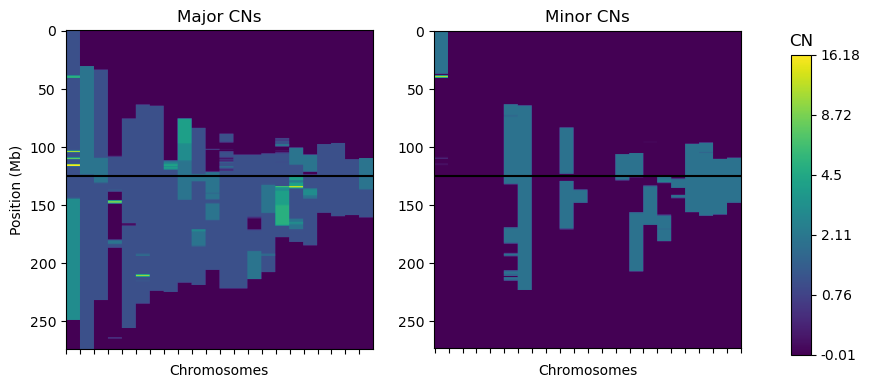

In [89]:
# Assuming sample is a numpy array with shape (2, 22, 275)

# Normalize the channels to the range [0, 1]
red_channel_norm = np.clip(red_channel, 0, 1)
green_channel_norm = np.clip(green_channel, 0, 1)

repeat = 12

# Repeat each row of the red and green channels 10 times
red_channel_norm_repeat = np.repeat(red_channel_norm, repeat, axis=0).T
green_channel_norm_repeat = np.repeat(green_channel_norm, repeat, axis=0).T

# Create a new figure and plot the RGB image
fig, ax = plt.subplots(1, 2, figsize=(10, 10), dpi=100)
ax[0].imshow(red_channel_norm_repeat)
ax[0].axhline(y=125, color='black', linestyle='-')
ax[1].imshow(green_channel_norm_repeat)
ax[1].axhline(y=125, color='black', linestyle='-')

# Set the y ticks with chromosome labels
for i in range(2):
    ax[i].set_xticks(np.arange(0, repeat*23, 12));
    ax[i].set_xticklabels([]);
    ax[i].set_xlabel('Chromosomes')

# set y label to position
ax[0].set_ylabel('Position (Mb)')

# set title to aligned CNs
ax[0].set_title('Major CNs')
ax[1].set_title('Minor CNs')

# create legend where the color range of the pixels goes between 0-1
# and the value of the pixel is shown in the colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.33, 0.02, 0.3])
cbar_ax.set_title('CN')
fig.colorbar(ax[0].imshow(red_channel_norm_repeat), cax=cbar_ax)

# Change the ticks of the colorbar axis
ticks = cbar_ax.get_yticks()
new_ticks = [np.exp(num * log_max) - 1.01 for num in ticks]
cbar_ax.set_yticklabels(np.round(new_ticks, decimals=2));

# set y label to position
# ax.set_ylabel('Position (Mb)')
# ax.set_xlabel('Chromosome')
# ax.set_xticks(np.arange(0, 12*22, 12));
# ax.set_xticklabels([]);